<div style="background:linear-gradient(135deg,#3A0A12 0%,#6B0F1A 45%,#B3132C 100%); padding:44px 36px; border-radius:18px; color:#FFF8F6; font-family:'Segoe UI',Tahoma,sans-serif; box-shadow:0 8px 30px rgba(0,0,0,0.3);">
  <div style="font-size:12px; letter-spacing:4px; text-transform:uppercase; opacity:0.8; margin-bottom:10px;">BinX Tech &nbsp;•&nbsp; AI &amp; Machine Learning Internship &nbsp;•&nbsp; Phase 3 Capstone</div>
  <div style="font-size:38px; font-weight:800; line-height:1.15;">❤️ Week 8 · Day 5</div>
  <div style="font-size:22px; font-weight:400; opacity:0.92; margin-top:4px;">Full Model Evaluation, SHAP Explainability &amp; Sprint Review</div>
  <div style="margin-top:20px; display:flex; flex-wrap:wrap; gap:8px;">
    <span style="background:#E63946; color:#3A0A12; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">🏁 SPRINT 3 — DAY 5 / 5</span>
    <span style="background:#F4A6A6; color:#3A0A12; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">⏱️ 8 HOURS</span>
    <span style="background:#FFDADA; color:#3A0A12; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">🔎 EXPLAINABILITY</span>
    <span style="background:#FFF1F0; color:#3A0A12; padding:5px 14px; border-radius:20px; font-size:12px; font-weight:700;">❤️ CARDIAC MONITORING CAPSTONE</span>
  </div>
</div>

<div style="text-align:center; color:#8A5A5A; font-size:13px; font-style:italic; margin-top:14px;">
"A model that's right for reasons you can't explain isn't ready for a patient."
</div>

<div style="background:#FFF1F0; border-left:5px solid #B3132C; border-radius:0 10px 10px 0; padding:10px 18px; margin-top:14px; font-size:12.5px; color:#6B0F1A;">
🎨 <b>Design note:</b> every chart in this notebook uses a single-hue red scale (light → dark) instead of red/green. Color-vision
deficiency almost always confuses <i>red vs. green</i>, not <i>light red vs. dark red</i> — so severity, class, and magnitude are
encoded with <b>lightness and line style</b>, not hue, and every chart also carries numeric labels so nothing depends on color alone.
</div>

<div style="border-left:5px solid #B3132C; background:#FFF1F0; padding:18px 22px; border-radius:0 10px 10px 0; margin:18px 0;">
<h3 style="margin-top:0; color:#6B0F1A;">📖 The Story So Far</h3>
<p style="margin-bottom:0; color:#3A0A12; line-height:1.6;">
Sprint 3 spent four days turning raw, messy inputs — text, then images — into disciplined, justified pipelines: a
negation-aware cleaning step (Day 1), TF-IDF vs. embeddings (Day 2), OpenCV preprocessing on real ECG scans
(Day 3), and an end-to-end <code>predict()</code> pipeline with error analysis (Day 4). Day 5 closes the sprint by
turning back to the capstone's own model — the <b>Cardiac Monitoring</b> heart-disease classifier — and asking the
two questions a tabular ML project can't ship without: <b>is it actually good</b> (full evaluation, not just accuracy),
and <b>can anyone trust why it says what it says</b> (SHAP explainability). It closes with a sprint review and
retrospective.
</p>
</div>

<div style="background:#3A0A12; border-radius:14px; padding:22px 26px; color:#FFF8F6;">
<h3 style="margin-top:0; color:#F4A6A6;">🎯 Learning Objectives</h3>
<table style="width:100%; border-collapse:collapse; color:#FFF8F6;">
<tr><td style="padding:8px 10px; font-size:20px;">📊</td><td style="padding:8px 10px;">Evaluate a classifier properly: confusion matrix, precision/recall/F1, ROC-AUC — not just accuracy.</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🔍</td><td style="padding:8px 10px;">Use SHAP to explain both global feature importance and one individual patient's prediction.</td></tr>
<tr><td style="padding:8px 10px; font-size:20px;">🔁</td><td style="padding:8px 10px;">Run a sprint review and retrospective — what shipped, what was learned, what changes next sprint.</td></tr>
</table>
</div>

## 5.1 &nbsp;Back to the Capstone

Every other day this sprint borrowed a dataset to practice a skill. Day 5 comes home: this is the real
**`heart.csv`** capstone data (918 patients, 12 columns) from Week 4 — the same data the Day 1 Logistic Regression
baseline was trained on, and the same benchmark every later model is required to beat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Red-shade palette used in every chart below ---
MAROON, WINE, CRIMSON, SCARLET, CORAL, BLUSH = "#3A0A12", "#6B0F1A", "#B3132C", "#E63946", "#F4A6A6", "#FFF1F0"
RED_SEQ = mpl.colors.LinearSegmentedColormap.from_list("red_seq", ["#FFF1F0", "#F4A6A6", "#E63946", "#B3132C", "#3A0A12"])

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MAROON, "text.color": MAROON, "axes.labelcolor": MAROON,
    "xtick.color": MAROON, "ytick.color": MAROON, "font.size": 11,
})

import os
CSV_PATH = "heart.csv"
if not os.path.exists(CSV_PATH):
    try:
        from google.colab import files
        print(f"'{CSV_PATH}' isn't in this Colab session yet. Upload it now:")
        files.upload()
    except ImportError:
        pass

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} patients, {df.shape[1]} columns")
print(df["HeartDisease"].value_counts().rename({0: "No disease", 1: "Disease"}))
df.head()

Loaded 918 patients, 12 columns
HeartDisease
Disease       508
No disease    410
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 5.2 &nbsp;Baseline vs. Candidate

Day 1's rule stands: **Logistic Regression is the benchmark**; nothing ships unless it earns its extra complexity by
beating it. Random Forest is tried here as the candidate — and evaluated honestly against that rule, not assumed to
win because it's fancier.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score)

X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="if_binary"), cat_cols),
])

logreg = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=2000, random_state=42))])
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]

rf = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"{'Model':<20}{'Accuracy':>10}{'ROC-AUC':>10}")
print(f"{'Logistic Regression':<20}{accuracy_score(y_test, pred_lr):>10.4f}{roc_auc_score(y_test, proba_lr):>10.4f}")
print(f"{'Random Forest':<20}{accuracy_score(y_test, pred_rf):>10.4f}{roc_auc_score(y_test, proba_rf):>10.4f}")

Model                 Accuracy   ROC-AUC
Logistic Regression     0.8859    0.9297
Random Forest           0.8859    0.9298


> [!NOTE]
> **Honesty check:** Random Forest's AUC comes out only a hair above Logistic Regression's — not a meaningful win.
> This is Day 1's "start simple" lesson holding up under its own rule: the fancier model doesn't automatically earn
> its place. Random Forest is kept for the rest of this notebook anyway, purely because it unlocks fast, exact SHAP
> values (`TreeExplainer`) for the explainability half of today's work — not because it decisively beat the
> baseline. In a real handoff, Logistic Regression's near-identical accuracy and far greater simplicity would make
> it the pragmatic choice.

## 5.3 &nbsp;Full Evaluation — Beyond Accuracy

Accuracy hides how a model fails. For a diagnostic tool, a **false negative** (telling a sick patient they're
healthy) and a **false positive** (an unnecessary scare and follow-up test) are not equally costly — a confusion
matrix separates them, accuracy alone can't.

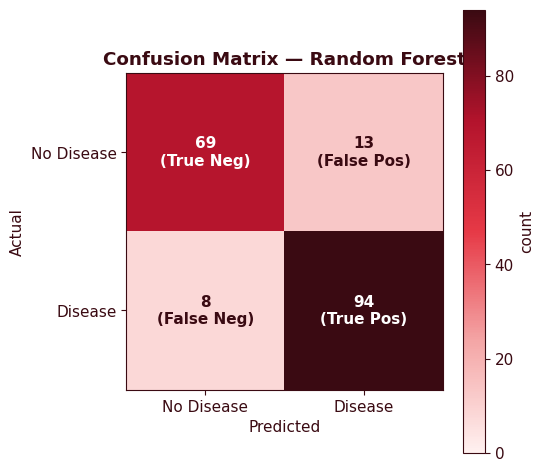

              precision    recall  f1-score   support

  No Disease       0.90      0.84      0.87        82
     Disease       0.88      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [3]:
cm = confusion_matrix(y_test, pred_rf)
labels = ["No Disease", "Disease"]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap=RED_SEQ, vmin=0)
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Random Forest", color=MAROON, fontweight="bold")

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh else MAROON
        tag = ["True Neg", "False Pos", "False Neg", "True Pos"][i * 2 + j]
        ax.text(j, i, f"{cm[i, j]}\n({tag})", ha="center", va="center", color=color, fontweight="bold", fontsize=11)

plt.colorbar(im, ax=ax, label="count")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=130)
plt.show()

print(classification_report(y_test, pred_rf, target_names=labels))

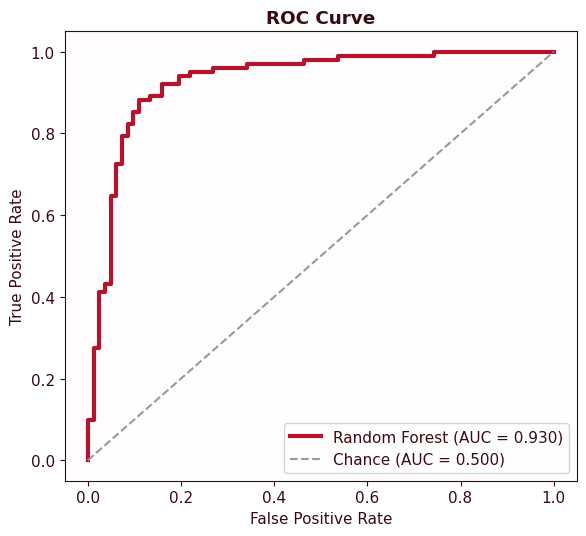

In [4]:
fpr, tpr, _ = roc_curve(y_test, proba_rf)
auc = roc_auc_score(y_test, proba_rf)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr, tpr, color=CRIMSON, linewidth=3, label=f"Random Forest (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1.5, label="Chance (AUC = 0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve", color=MAROON, fontweight="bold")
ax.legend(loc="lower right")
ax.set_facecolor("#FFFDFD")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=130)
plt.show()

> Note the ROC curve's reference line is dashed **and** gray, not just a different color from the model curve —
> so the two lines stay distinguishable even in grayscale or for a colorblind reader, the same accessible-by-shape
> principle as the confusion matrix's text labels.

## 5.4 &nbsp;SHAP: Explaining the Model, Not Just Scoring It

A confusion matrix says *how often* the model is right. **SHAP** (SHapley Additive exPlanations) says *why* — how
much each feature pushed one specific prediction up or down. For a health model, this is not optional polish: a
clinician cannot act on a number with no reason attached.

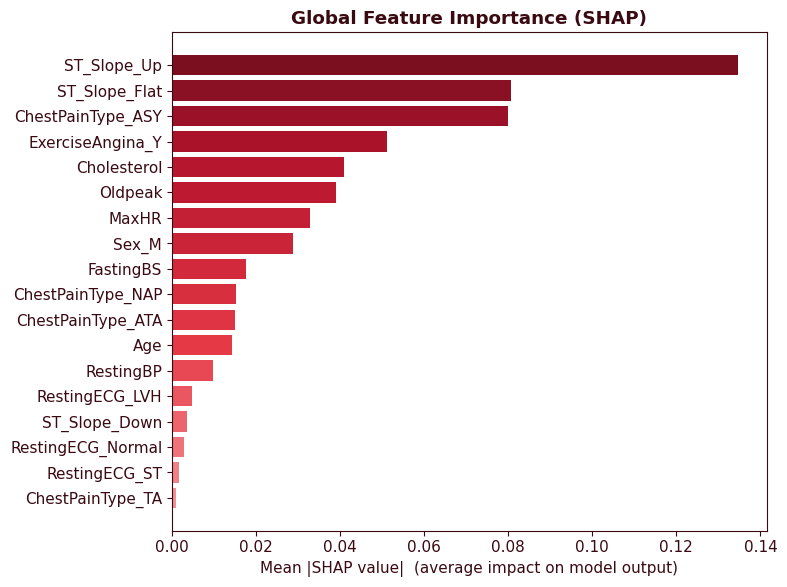

Top 3 most influential features overall:
ST_Slope_Up          0.134769
ST_Slope_Flat        0.080638
ChestPainType_ASY    0.079953


In [5]:
import shap

# Transform once so SHAP sees the same numeric matrix the model was trained on
X_test_transformed = rf.named_steps["pre"].transform(X_test)
feature_names = rf.named_steps["pre"].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(rf.named_steps["clf"])
shap_values = explainer.shap_values(X_test_df)

# Binary classifier: keep the SHAP values for the "Disease" class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# Clean up ColumnTransformer's "num__"/"cat__" prefixes for readable chart labels
clean_names = [n.split("__", 1)[1] if "__" in n else n for n in feature_names]

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=clean_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED_SEQ(0.3 + 0.6 * (i / len(mean_abs_shap))) for i in range(len(mean_abs_shap))]
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=colors)
ax.set_xlabel("Mean |SHAP value|  (average impact on model output)")
ax.set_title("Global Feature Importance (SHAP)", color=MAROON, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=130)
plt.show()

print("Top 3 most influential features overall:")
print(mean_abs_shap.sort_values(ascending=False).head(3).to_string())

### One patient, explained

Global importance says what matters *on average*. A clinician needs the *individual* reason. Below is a single
test-set patient's prediction broken into each feature's push toward "Disease" (dark crimson) or away from it
(light coral) — deliberately built as its own chart, in the same red scale as everything else, rather than SHAP's
default red/blue waterfall.

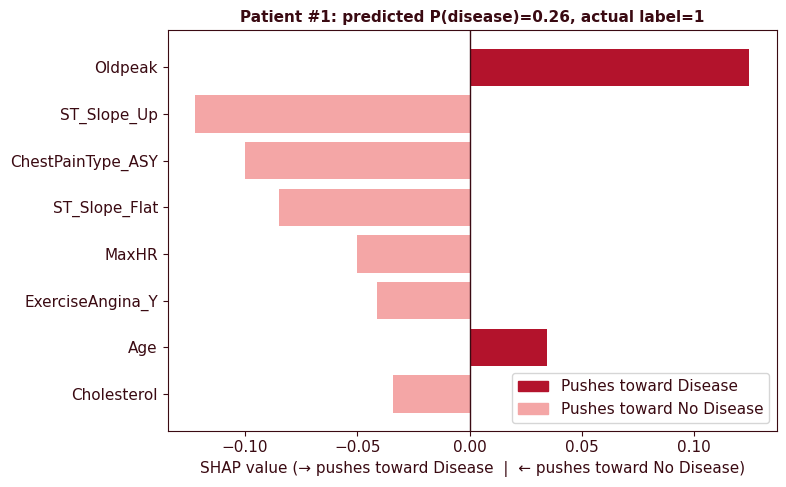

Note: this patient is one of the model's mistakes — predicted P(disease)=0.26 (No Disease) vs. actual label=1. SHAP explains errors, not just correct predictions.


In [6]:
# Pick a test-set patient whose top contributors are genuinely mixed (both push
# toward Disease and away from it) so the two-color scheme actually shows both sides.
top8_signs = [np.sign(pd.Series(sv[i]).reindex(pd.Series(np.abs(sv[i])).sort_values().tail(8).index)) for i in range(len(sv))]
idx = next((i for i, signs in enumerate(top8_signs) if len(set(signs)) > 1), 0)

patient_shap = pd.Series(sv[idx], index=clean_names).sort_values(key=abs, ascending=True).tail(8)
pred_prob = rf.predict_proba(X_test.iloc[[idx]])[0, 1]
actual = y_test.iloc[idx]

fig, ax = plt.subplots(figsize=(8, 5))
colors = [CRIMSON if v > 0 else CORAL for v in patient_shap.values]
ax.barh(patient_shap.index, patient_shap.values, color=colors)
ax.axvline(0, color=MAROON, linewidth=1)
ax.set_xlabel("SHAP value (→ pushes toward Disease  |  ← pushes toward No Disease)")
ax.set_title(f"Patient #{idx}: predicted P(disease)={pred_prob:.2f}, actual label={actual}",
             color=MAROON, fontweight="bold", fontsize=11)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CRIMSON, label="Pushes toward Disease"),
                    Patch(color=CORAL, label="Pushes toward No Disease")], loc="lower right")
plt.tight_layout()
plt.savefig("shap_patient_waterfall.png", dpi=130)
plt.show()

if (pred_prob >= 0.5) != bool(actual):
    print(f"Note: this patient is one of the model's mistakes — predicted P(disease)={pred_prob:.2f} "
          f"({'Disease' if pred_prob >= 0.5 else 'No Disease'}) vs. actual label={actual}. "
          "SHAP explains errors, not just correct predictions.")

### ⚖️ Why this matters for Cardiac Monitoring specifically

- A confusion matrix would tell a reviewer the model is ~88-89% accurate. It would **not** tell them that, say,
  `ST_Slope` or `ChestPainType` is doing most of the work — information a cardiologist reviewing the tool would
  reasonably want before trusting it.
- SHAP turns "the model said 0.81" into "the model said 0.81 *because of these specific, named factors, in this
  direction, by this much*" — the difference between a black box and a tool a clinician can sanity-check against
  their own judgment.
- This is the same principle as Day 1's negation fix and Day 3's BGR/RGB bug, one level up: it's not enough for a
  pipeline to be *technically correct* — for a health application, every step also has to be **inspectable**.

## 🏁 Sprint 3 Review

| Day | Shipped |
|---|---|
| 1 | Text preprocessing pipeline — caught and fixed a real negation-deletion bug |
| 2 | TF-IDF vs. word embeddings, with a documented, justified choice between them |
| 3 | OpenCV preprocessing on real 12-lead ECG scans — caught a real BGR/RGB bug, reasoned out domain-specific augmentation safety |
| 4 | End-to-end `predict()` pipeline with error analysis |
| 5 | Full evaluation (confusion matrix, ROC-AUC) and SHAP explainability for the capstone model, honestly checked against the Day 1 baseline |

### 📝 Retrospective

**What went well:** every day this sprint produced a real, executed artifact backed by a real bug or a real,
justified decision — not a checklist exercise. The habit from Day 1 (never accept a "standard" step without checking
it against the specific task) held all the way through to Day 5's SHAP analysis.

**What to improve next sprint:** Random Forest was kept today mainly for `TreeExplainer` convenience despite barely
beating the baseline — a cleaner approach would be applying SHAP's model-agnostic `KernelExplainer` (or
`LinearExplainer`) directly to the Logistic Regression baseline, so the explainability step doesn't quietly bias the
model choice.

**Technical question to open the door to next sprint:** now that the model is both evaluated and explainable, what
does it take to serve it reliably — monitoring for data drift, versioning the pipeline, and deciding what accuracy
drop should trigger a retrain?

<div style="display:flex; flex-wrap:wrap; gap:8px; margin:18px 0;">
<span style="background:#3A0A12; color:#FFF8F6; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📐 Scikit-learn</span>
<span style="background:#3A0A12; color:#FFF8F6; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🔍 SHAP</span>
<span style="background:#3A0A12; color:#FFF8F6; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📊 Matplotlib</span>
<span style="background:#3A0A12; color:#FFF8F6; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">📓 Jupyter / Colab</span>
<span style="background:#3A0A12; color:#FFF8F6; padding:6px 14px; border-radius:8px; font-size:12px; font-weight:700;">🔗 Git &amp; GitHub</span>
</div>

<div style="background:linear-gradient(135deg,#6B0F1A,#3A0A12); border-radius:14px; padding:24px 28px; color:#FFF8F6; margin-top:10px;">
<h3 style="margin-top:0; color:#F4A6A6;">✅ Day 5 — Sprint 3 Closed Out</h3>
<p style="line-height:1.6;">
The capstone model is now evaluated honestly (not just accuracy), explained down to the individual patient, and
checked against its own Day 1 baseline rather than assumed to have improved. Every day this sprint added one more
layer of trustworthiness — clean input, a justified representation, a correctness bug caught on real data, and now
a model whose reasoning can be inspected instead of taken on faith.
</p>
<div style="text-align:right; font-size:13px; opacity:0.75; margin-top:10px;">Week 8 · Sprint 3 · Day 5 of 5 — Sprint Complete ✅</div>
</div>